# Run Wela
This notebook contains step-to-step guides to run wela, including debugging processes

## Examples
Before running wela, alibylite must be ran for the experiments of interest, and to produce h5 files containing information from the microscopy pictures taken. These h5 files should then be postprocessed

In [1]:
from pathlib import Path

import h5py
from postprocessor.core.postprocessing import PostProcessor, PostProcessorParameters
from postprocessor.grouper import Grouper
from wela.imageviewer import get_h5files

h5dir = "/home/ianyang/alibylite/data/"
omids = [
    "1908_2023_09_05_18360_2020_01_04_steadystate_glucose_2min_01",
    # "18446_2020_01_08_steadystate_glucose_2w0p1_2min_01",
]
omid = omids[0]

# run postprocessing
for h5file in ["898_002.h5","898_003.h5","1106_009.h5","1106_007.h5","900_005.h5","1106_008.h5","898_001.h5","900_004.h5"]:
    filepath = Path(h5dir + omid + "/" + h5file)
    with h5py.File(filepath, "a") as f:
        print(f"re-processing {h5file.split('.')[0]}")
        if "postprocessing" in f:
            del f["/postprocessing"]
        if "modifiers" in f:
            del f["/modifiers"]
        params = PostProcessorParameters.default()
        pp = PostProcessor(filepath, params)
        pp.run()

re-processing 898_002


100%|██████████| 2/2 [00:01<00:00,  1.35it/s]


re-processing 898_003


100%|██████████| 2/2 [00:01<00:00,  1.30it/s]


re-processing 1106_009


...

100%|██████████| 2/2 [00:01<00:00,  1.24it/s]


re-processing 898_001


100%|██████████| 2/2 [00:01<00:00,  1.64it/s]


re-processing 900_004


100%|██████████| 2/2 [00:01<00:00,  1.51it/s]


We then want to load the data from the h5 files by creating a tsv file from the h5 files

In [3]:
import sys
sys.path.append('/home/ianyang/wela/src')
from wela.dataloader import dataloader as dataloader
dataname = "1908_2023_09_05_18360_2020_01_04_steadystate_glucose_2min_01"
h5dir = "/home/ianyang/alibylite/data"
wdir = "."
dl = dataloader(h5dir = h5dir, wdir = wdir)
dl.load(dataname)
dl.save()


Data directory is /home/ianyang/alibylite/data
Experiments available:
{0: '1613_2023_04_05_steady_0_1_gluc_2min_msn2msn4_00',
 1: '1864_2023_08_25_19392_2020_11_12_steadystate_glucose_898m_2w0p01_00',
 2: '1853_2023_08_23_18572_2020_02_04_steady_2p0glc_2min_3z_mch5V_msn4msn2_00',
 3: '1861_2023_08_23_18446_2020_01_08_steadystate_glucose_2w0p1_2min_01',
 4: '469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01',
 5: '1908_2023_09_05_18360_2020_01_04_steadystate_glucose_2min_01',
 6: '1862_2023_08_24_19477_2020_11_27_steadystate_glucose_898_exposure_901_2w0p01_00',
 7: '1867_2023_08_28_19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00',
 8: '1863_2023_08_24_19554_2020_12_06_steadystate_glucose_2w0p01_900m_00'}

Working directory is /home/ianyang/wela/data_analysis
Datasets available:
{0: '18464_2020_01_20_steadystate_glucose_756S_2min_mock_00.tsv',
 1: '19316_2020_10_26_steadystate_glucose_144m_2w2_00.tsv',
 2: '1908_2023_09_05_18360_2020_01_04_steadystate_glucose_2min_01.tsv',
 3:

KeyboardInterrupt: 

The below plots the tsv files generated


Data directory is /home/ianyang/alibylite/data
Experiments available:
{0: '1613_2023_04_05_steady_0_1_gluc_2min_msn2msn4_00',
 1: '1864_2023_08_25_19392_2020_11_12_steadystate_glucose_898m_2w0p01_00',
 2: '1853_2023_08_23_18572_2020_02_04_steady_2p0glc_2min_3z_mch5V_msn4msn2_00',
 3: '1861_2023_08_23_18446_2020_01_08_steadystate_glucose_2w0p1_2min_01',
 4: '469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01',
 5: '1908_2023_09_05_18360_2020_01_04_steadystate_glucose_2min_01',
 6: '1862_2023_08_24_19477_2020_11_27_steadystate_glucose_898_exposure_901_2w0p01_00',
 7: '1867_2023_08_28_19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00',
 8: '1863_2023_08_24_19554_2020_12_06_steadystate_glucose_2w0p01_900m_00'}

Working directory is /home/ianyang/wela/data_analysis
Datasets available:
{0: '18464_2020_01_20_steadystate_glucose_756S_2min_mock_00.tsv',
 1: '19316_2020_10_26_steadystate_glucose_144m_2w2_00.tsv',
 2: '1908_2023_09_05_18360_2020_01_04_steadystate_glucose_2min_01.tsv',
 3:

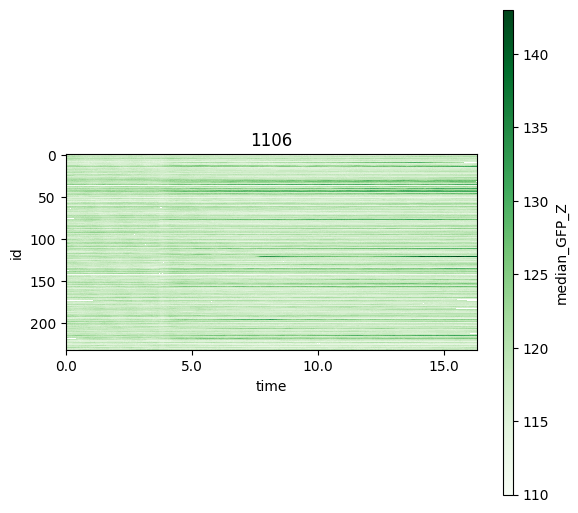

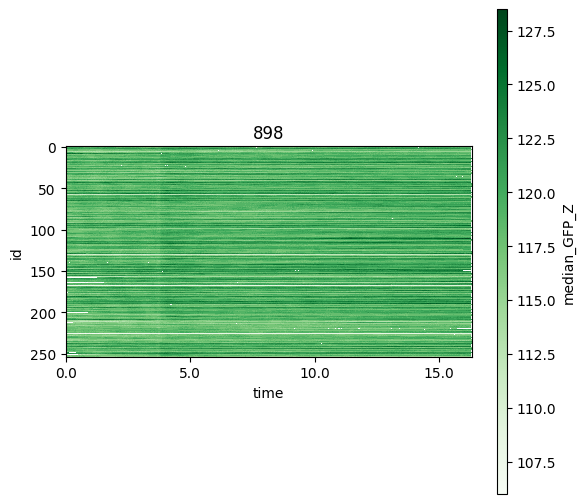

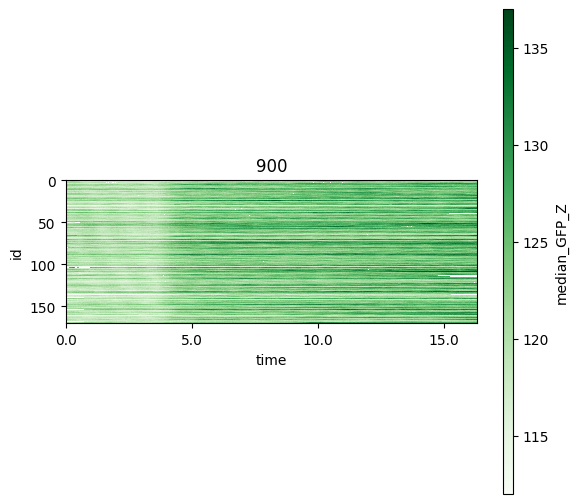

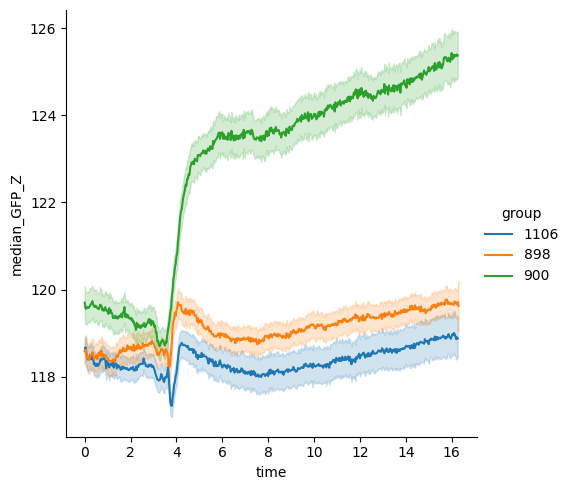

In [6]:
import sys

import matplotlib.pylab as plt
import seaborn as sns
from wela.dataloader import dataloader
from wela.imageviewer import ImageViewer, get_h5files
from wela.plotting import kymograph
from wela.sorting import sort_by_budding

h5dir = "/home/ianyang/alibylite/data/"
omids = [
    '1864_2023_08_25_19392_2020_11_12_steadystate_glucose_898m_2w0p01_00','1853_2023_08_23_18572_2020_02_04_steady_2p0glc_2min_3z_mch5V_msn4msn2_00',
    '1861_2023_08_23_18446_2020_01_08_steadystate_glucose_2w0p1_2min_01',
    '469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01',
    '1908_2023_09_05_18360_2020_01_04_steadystate_glucose_2min_01',
    '1862_2023_08_24_19477_2020_11_27_steadystate_glucose_898_exposure_901_2w0p01_00','1867_2023_08_28_19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00','1863_2023_08_24_19554_2020_12_06_steadystate_glucose_2w0p01_900m_00'
]
# FILL IN
server_info = {
    "host": "staffa.bio.ed.ac.uk",
    "username": "upload",
    "password": "gothamc1ty",
}
view = False
# pick the experiment to analyse
omid = 1908

# 1. Run with view=True to check visually that aliby has worked correctly.
# 2. Set key_index, the signal you are most interested in.
# 3. Run with view=False to run dataloader and save a tsv file.

if view:
    omero_name = [om for om in omids if str(omid) in om][0]
    h5files = get_h5files(h5dir, omero_name)
    position = h5files[0]
    h5file = f"{h5dir}{omero_name}/{position}"
    iv = ImageViewer.remote(h5file, server_info, omid)
    tpt_end = 10
    no_cells = 6
    iv.view(
        trap_ids=iv.sample_traps_with_cells(
            tpt_end=tpt_end, no_cells=no_cells
        ),
        tpt_end=tpt_end,
        channels_to_skip=["cy5"],
        no_rows=2,
    )
    sys.exit(0)
else:
    # run dataloader
    key_index = "median_GFP_Z" # sometimes this is "median_GFP_Z" instead of "median_GFP"
    dl = dataloader(h5dir, ".")
    dl.define_g2a_dict(fl_channels=["GFP_Z"]) # sometimes this is ["GFP"] instead of ["GFP_Z"], and we need to set fl_channels=["GFP_Z"]
    expt = [omid_full for omid_full in omids if str(omid) in omid_full][0]
    dl.load(expt, key_index=key_index, cutoff=0.9)
    dl.save()

    # plot kymographs
    groups = dl.df.group.unique()
    for group in groups:
        _, buddings = dl.get_time_series("buddings", group=group)
        sort_order = sort_by_budding(buddings)
        kymograph(
            dl.df[dl.df.group == group],
            hue=key_index,
            title=group,
            sort_order=sort_order,
        )

    # plot means
    sns.relplot(data=dl.df, x="time", y=key_index, kind="line", hue="group")
    plt.show()


Data directory is /home/ianyang/alibylite/data
Experiments available:
{0: '1864_2023_08_25_19392_2020_11_12_steadystate_glucose_898m_2w0p01_00',
 1: '1853_2023_08_23_18572_2020_02_04_steady_2p0glc_2min_3z_mch5V_msn4msn2_00',
 2: '1861_2023_08_23_18446_2020_01_08_steadystate_glucose_2w0p1_2min_01',
 3: '469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01',
 4: '1908_2023_09_05_18360_2020_01_04_steadystate_glucose_2min_01',
 5: '1862_2023_08_24_19477_2020_11_27_steadystate_glucose_898_exposure_901_2w0p01_00',
 6: '1867_2023_08_28_19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00',
 7: '1863_2023_08_24_19554_2020_12_06_steadystate_glucose_2w0p01_900m_00'}

Working directory is /home/ianyang/wela/data_analysis
Datasets available:
{0: '469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01.tsv'}

---
469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01
---
Signals available:
  extraction/GFP/max/imBackground
  extraction/GFP/max/max5px_median
  extraction/GFP/max/mean
  extraction/

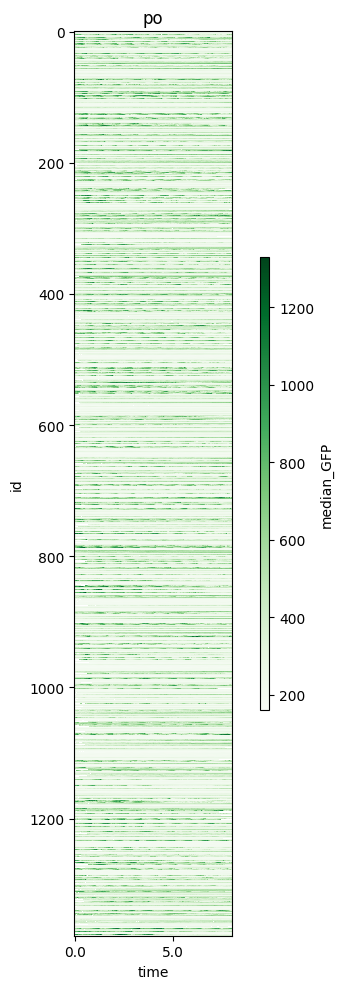

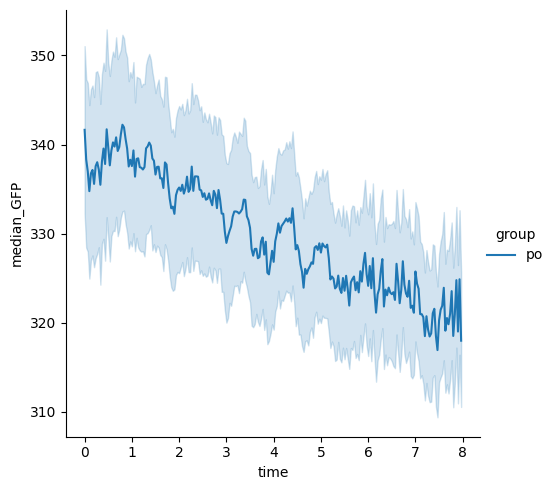

In [ ]:
import sys

import matplotlib.pylab as plt
import seaborn as sns
from wela.dataloader import dataloader
from wela.imageviewer import ImageViewer, get_h5files
from wela.plotting import kymograph
from wela.sorting import sort_by_budding

h5dir = "/home/ianyang/alibylite/data/"
omids = [
    "469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01",
]
# FILL IN
server_info = {
    "host": "staffa.bio.ed.ac.uk",
    "username": "upload",
    "password": "gothamc1ty",
}
view = False
# pick the experiment to analyse
omid = 469

# 1. Run with view=True to check visually that aliby has worked correctly.
# 2. Set key_index, the signal you are most interested in.
# 3. Run with view=False to run dataloader and save a tsv file.

if view:
    omero_name = [om for om in omids if str(omid) in om][0]
    h5files = get_h5files(h5dir, omero_name)
    position = h5files[0]
    h5file = f"{h5dir}{omero_name}/{position}"
    iv = ImageViewer.remote(h5file, server_info, omid)
    tpt_end = 10
    no_cells = 6
    iv.view(
        trap_ids=iv.sample_traps_with_cells(
            tpt_end=tpt_end, no_cells=no_cells
        ),
        tpt_end=tpt_end,
        channels_to_skip=["cy5"],
        no_rows=2,
    )
    sys.exit(0)
else:
    # run dataloader
    key_index = "median_GFP"
    dl = dataloader(h5dir, ".")
    expt = [omid_full for omid_full in omids if str(omid) in omid_full][0] # this line doesnt need to be run if the experiment has a customised ID. 
    dl.load(expt, key_index=key_index, cutoff=0.9)
    dl.save()

    # plot kymographs
    groups = dl.df.group.unique()
    for group in groups:
        _, buddings = dl.get_time_series("buddings", group=group)
        sort_order = sort_by_budding(buddings)
        kymograph(
            dl.df[dl.df.group == group],
            hue=key_index,
            title=group,
            sort_order=sort_order,
        )

    # plot means
    sns.relplot(data=dl.df, x="time", y=key_index, kind="line", hue="group")
    plt.show()

In [ ]:
from pathlib import Path

import h5py
from postprocessor.core.postprocessing import PostProcessor, PostProcessorParameters
from postprocessor.grouper import Grouper
from wela.imageviewer import get_h5files

h5dir = "/home/ianyang/alibylite/data/"
omids = [
    "469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01",
    # "18446_2020_01_08_steadystate_glucose_2w0p1_2min_01",
]
omid = omids[0]

# run postprocessing
for h5file in ['pos001.h5','pos002.h5','pos003.h5','pos004.h5','pos005.h5',
'pos006.h5','pos007.h5','pos008.h5',
'pos009.h5','pos010.h5','pos011.h5','pos012.h5','pos013.h5','pos014.h5','pos015.h5','pos016.h5'
'pos017.h5','pos018.h5','pos019.h5','pos020.h5']:
    filepath = Path(h5dir + omid + "/" + h5file)
    with h5py.File(filepath, "a") as f:
        print(f"re-processing {h5file.split('.')[0]}")
        if "postprocessing" in f:
            del f["/postprocessing"]
        if "modifiers" in f:
            del f["/modifiers"]
        params = PostProcessorParameters.default()
        pp = PostProcessor(filepath, params)
        pp.run()

import sys
sys.path.append('/home/ianyang/wela/src')
from wela.dataloader import dataloader as dataloader
dataname = "469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01"
h5dir = "/home/ianyang/alibylite/data"
wdir = "."
dl = dataloader(h5dir = h5dir, wdir = wdir)
dl.load(dataname)
dl.save()

re-processing pos001


AttributeError: 'NoneType' object has no attribute 'shape'

Set view = True to view something in a GUI

In [1]:
import sys

import matplotlib.pylab as plt
import seaborn as sns
from wela.dataloader import dataloader
from wela.imageviewer import ImageViewer, get_h5files
from wela.plotting import kymograph
from wela.sorting import sort_by_budding

h5dir = "/home/ianyang/alibylite/data/"
omids = [
    "469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01",
    # "2003_2024_01_29_2pc_switch_00",
    # "2008_2024_02_12_Rpl3_glc_raf_switching_00",
]
# FILL IN
server_info = {
    "host": "staffa.bio.ed.ac.uk",
    "username": "upload",
    "password": "gothamc1ty",
}
view = True
# pick the experiment to analyse
omid = 469 # expt_id

# 1. Run with view=True to check visually that aliby has worked correctly.
# 2. Set key_index, the signal you are most interested in.
# 3. Run with view=False to run dataloader and save a tsv file.

if view:
    omero_name = [om for om in omids if str(omid) in om][0]
    h5files = get_h5files(h5dir, omero_name)
    position = h5files[0]
    h5file = f"{h5dir}{omero_name}/{position}"
    iv = ImageViewer.remote(h5file, server_info, omid)
    tpt_end = 10
    no_cells = 6
    iv.view(
        trap_ids=iv.sample_traps_with_cells(
            tpt_end=tpt_end, no_cells=no_cells
        ),
        tpt_end=tpt_end,
        channels_to_skip=["cy5"],
        no_rows=2,
    )
    sys.exit(0)
else:
    # run dataloader
    key_index = "median_GFP"
    dl = dataloader(h5dir, ".")
    expt = [omid_full for omid_full in omids if str(omid) in omid_full][0]
    dl.load(expt, key_index=key_index, cutoff=0.8)
    dl.save()

    # plot kymographs
    groups = dl.df.group.unique()
    for group in groups:
        _, buddings = dl.get_time_series("buddings", group=group)
        sort_order = sort_by_budding(buddings)
        kymograph(
            dl.df[dl.df.group == group],
            hue=key_index,
            title=group,
            sort_order=sort_order,
        )

    # plot means
    sns.relplot(data=dl.df, x="time", y=key_index, kind="line", hue="group")
    plt.show()

Viewing /home/ianyang/alibylite/data/469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01/pos001.h5
Using image ID 36668.
Connected to OMERO.
Getting GFP at time point 0.
Getting GFP at time point 1.
Getting GFP at time point 2.
Getting GFP at time point 3.
Getting GFP at time point 4.
Getting GFP at time point 5.
Getting GFP at time point 6.
Getting GFP at time point 7.
Getting GFP at time point 8.
Getting GFP at time point 9.
Getting GFP at time point 10.
Getting Brightfield at time point 0.
Getting Brightfield at time point 1.
Getting Brightfield at time point 2.
Getting Brightfield at time point 3.
Getting Brightfield at time point 4.
Getting Brightfield at time point 5.
Getting Brightfield at time point 6.
Getting Brightfield at time point 7.
Getting Brightfield at time point 8.
Getting Brightfield at time point 9.
Getting Brightfield at time point 10.
Combining tiles...



Available platform plugins are: eglfs, minimal, minimalegl, offscreen, vnc, webgl, xcb.



: 

In [4]:
import sys
sys.path.append('/home/ianyang/wela/src')
from wela.dataloader import dataloader as dataloader
dataname = "1613_2023_04_05_steady_0_1_gluc_2min_msn2msn4_00"
h5dir = "/home/ianyang/alibylite/data"
wdir = "."
dl = dataloader(h5dir = h5dir, wdir = wdir)
dl.load(dataname)
dl.save()


Data directory is /home/ianyang/alibylite/data
Experiments available:
{0: '1613_2023_04_05_steady_0_1_gluc_2min_msn2msn4_00',
 1: '1864_2023_08_25_19392_2020_11_12_steadystate_glucose_898m_2w0p01_00',
 2: '1853_2023_08_23_18572_2020_02_04_steady_2p0glc_2min_3z_mch5V_msn4msn2_00',
 3: '1861_2023_08_23_18446_2020_01_08_steadystate_glucose_2w0p1_2min_01',
 4: '469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01',
 5: '1908_2023_09_05_18360_2020_01_04_steadystate_glucose_2min_01',
 6: '1862_2023_08_24_19477_2020_11_27_steadystate_glucose_898_exposure_901_2w0p01_00',
 7: '1867_2023_08_28_19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00',
 8: '1863_2023_08_24_19554_2020_12_06_steadystate_glucose_2w0p01_900m_00'}

Working directory is /home/ianyang/wela/data_analysis
Datasets available:
{0: '469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01.tsv'}

---
1613_2023_04_05_steady_0_1_gluc_2min_msn2msn4_00
---
Signals available:
  extraction/general/None/absolute_x
  extraction/general/


Data directory is /home/ianyang/alibylite/data
Experiments available:
{0: '1613_2023_04_05_steady_0_1_gluc_2min_msn2msn4_00',
 1: '1864_2023_08_25_19392_2020_11_12_steadystate_glucose_898m_2w0p01_00',
 2: '1853_2023_08_23_18572_2020_02_04_steady_2p0glc_2min_3z_mch5V_msn4msn2_00',
 3: '1861_2023_08_23_18446_2020_01_08_steadystate_glucose_2w0p1_2min_01',
 4: '469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01',
 5: '1908_2023_09_05_18360_2020_01_04_steadystate_glucose_2min_01',
 6: '1862_2023_08_24_19477_2020_11_27_steadystate_glucose_898_exposure_901_2w0p01_00',
 7: '1867_2023_08_28_19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00',
 8: '1863_2023_08_24_19554_2020_12_06_steadystate_glucose_2w0p01_900m_00'}

Working directory is /home/ianyang/wela/data_analysis
Datasets available:
{0: '1613_2023_04_05_steady_0_1_gluc_2min_msn2msn4_00.tsv',
 1: '469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01.tsv'}

---
1613_2023_04_05_steady_0_1_gluc_2min_msn2msn4_00
---
Signals available

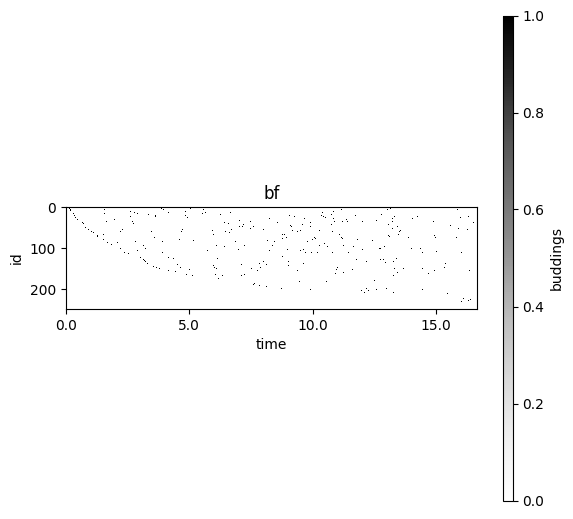

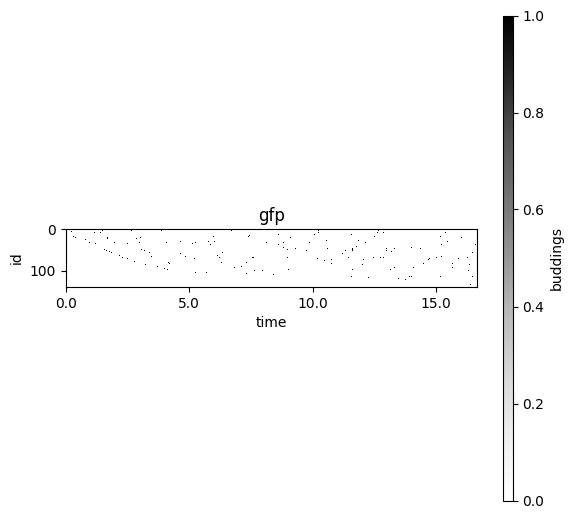

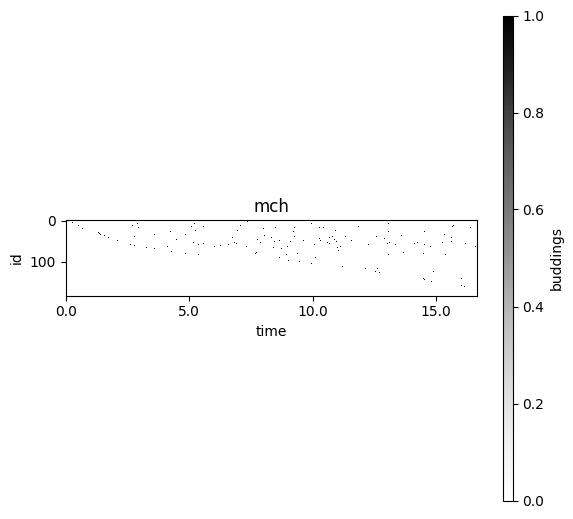

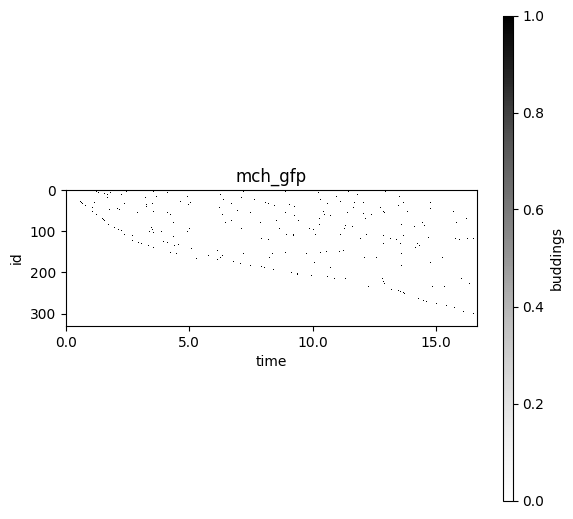

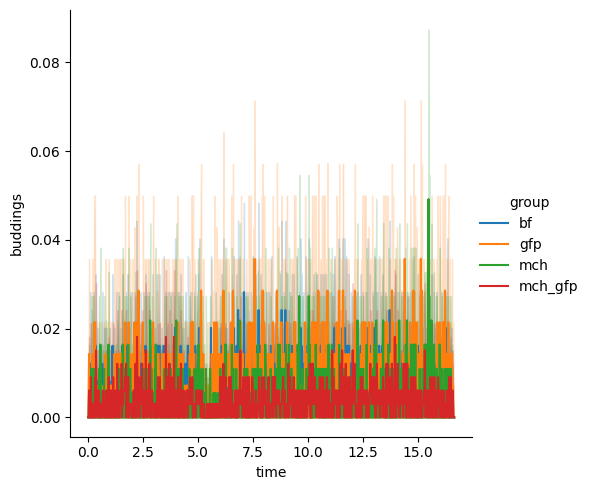

In [1]:
import sys

import matplotlib.pylab as plt
import seaborn as sns
from wela.dataloader import dataloader
from wela.imageviewer import ImageViewer, get_h5files
from wela.plotting import kymograph
from wela.sorting import sort_by_budding

h5dir = "/home/ianyang/alibylite/data/"
omids = [
    '1864_2023_08_25_19392_2020_11_12_steadystate_glucose_898m_2w0p01_00','1853_2023_08_23_18572_2020_02_04_steady_2p0glc_2min_3z_mch5V_msn4msn2_00',
    '1861_2023_08_23_18446_2020_01_08_steadystate_glucose_2w0p1_2min_01',
    '469_2022_11_15_morph_5cham_hog1_lte1_htb2_vph1_bud3_01',
    '1908_2023_09_05_18360_2020_01_04_steadystate_glucose_2min_01',
    '1862_2023_08_24_19477_2020_11_27_steadystate_glucose_898_exposure_901_2w0p01_00','1867_2023_08_28_19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00','1863_2023_08_24_19554_2020_12_06_steadystate_glucose_2w0p01_900m_00',
    '1613_2023_04_05_steady_0_1_gluc_2min_msn2msn4_00',
]
# FILL IN
server_info = {
    "host": "staffa.bio.ed.ac.uk",
    "username": "upload",
    "password": "gothamc1ty",
}
view = False
# pick the experiment to analyse
omid = 1613

# 1. Run with view=True to check visually that aliby has worked correctly.
# 2. Set key_index, the signal you are most interested in.
# 3. Run with view=False to run dataloader and save a tsv file.

if view:
    omero_name = [om for om in omids if str(omid) in om][0]
    h5files = get_h5files(h5dir, omero_name)
    position = h5files[0]
    h5file = f"{h5dir}{omero_name}/{position}"
    iv = ImageViewer.remote(h5file, server_info, omid)
    tpt_end = 10
    no_cells = 6
    iv.view(
        trap_ids=iv.sample_traps_with_cells(
            tpt_end=tpt_end, no_cells=no_cells
        ),
        tpt_end=tpt_end,
        channels_to_skip=["cy5"],
        no_rows=2,
    )
    sys.exit(0)
else:
    # run dataloader
    key_index = "buddings"
    dl = dataloader(h5dir, ".")
    dl.define_g2a_dict()
    expt = [omid_full for omid_full in omids if str(omid) in omid_full][0]
    dl.load(expt, key_index=key_index, cutoff=0.9)
    dl.save()

    # plot kymographs
    groups = dl.df.group.unique()
    for group in groups:
        _, buddings = dl.get_time_series("buddings", group=group)
        sort_order = sort_by_budding(buddings)
        kymograph(
            dl.df[dl.df.group == group],
            hue=key_index,
            title=group,
            sort_order=sort_order,
        )

    # plot means
    sns.relplot(data=dl.df, x="time", y=key_index, kind="line", hue="group")
    plt.show()

In [6]:
dl.a2g_dict

{'cy5': 'extraction/cy5/max/median',
 'area': 'extraction/general/None/area',
 'volume': 'extraction/general/None/volume',
 'image_x': 'extraction/general/None/image_x',
 'image_y': 'extraction/general/None/image_y',
 'absolute_x': 'extraction/general/None/absolute_x',
 'absolute_y': 'extraction/general/None/absolute_y',
 'flavin': 'extraction/Flavin_bgsub/max/mean',
 'buddings': 'postprocessing/buddings/extraction_general_None_volume',
 'bud_volume': 'postprocessing/bud_metric/extraction_general_None_volume',
 'bud_area': 'postprocessing/bud_metric/extraction_general_None_area',
 'median_GFP': 'extraction/GFP/max/median',
 'mean_GFP': 'extraction/GFP/max/mean',
 'std_GFP': 'extraction/GFP/max/std',
 'max5px_median_GFP': 'extraction/GFP/max/max5px_median',
 'nuc_est_conv_GFP': 'extraction/GFP/max/nuc_est_conv',
 'bud_median_GFP': 'postprocessing/bud_metric/extraction_GFP_max_median',
 'bud_mean_GFP': 'postprocessing/bud_metric/extraction_GFP_max_mean',
 'bud_std_GFP': 'postprocessing/b

## High quality data analysis

In [1]:
import glob
import os
import sys
import pandas as pd
import traceback

from pathlib import Path

import h5py
from postprocessor.core.postprocessing import PostProcessor, PostProcessorParameters
from postprocessor.grouper import Grouper
from wela.imageviewer import get_h5files

h5dir = "/home/ianyang/alibylite/high_quality_data_analysis/"
exp_list = pd.read_csv("/home/ianyang/alibylite/high_quality_data_analysis/exp_list.csv")
omids = exp_list["exp_name"].tolist()

for omid in omids:
    try:
        for h5file in glob.glob(h5dir + omid + "/*.h5"):
            filepath = Path(h5file)
            try:
                with h5py.File(filepath, "a") as f:
                    print(f"re-processing {h5file.split('.')[0]}")
                    if "postprocessing" in f:
                        del f["/postprocessing"]
                    if "modifiers" in f:
                        del f["/modifiers"]
                    params = PostProcessorParameters.default()
                    pp = PostProcessor(filepath, params)
                    pp.run()
            except Exception as e:
                print(f"Error processing {h5file}: {str(e)}")
                traceback.print_exc()
    except Exception as e:
        print(f"Error processing experiment {omid}: {str(e)}")
        traceback.print_exc()

re-processing /home/ianyang/alibylite/high_quality_data_analysis/18446_2020_01_08_steadystate_glucose_2w0p1_2min_01/pos001


100%|██████████| 2/2 [00:01<00:00,  1.62it/s]


re-processing /home/ianyang/alibylite/high_quality_data_analysis/18446_2020_01_08_steadystate_glucose_2w0p1_2min_01/pos009


100%|██████████| 2/2 [00:01<00:00,  1.65it/s]


re-processing /home/ianyang/alibylite/high_quality_data_analysis/18446_2020_01_08_steadystate_glucose_2w0p1_2min_01/pos003


...

100%|██████████| 2/2 [00:01<00:00,  1.15it/s]


re-processing /home/ianyang/alibylite/high_quality_data_analysis/19394_2020_11_12_steadystate_glucose_1345m_2w0p1_00/1349_007


100%|██████████| 2/2 [00:01<00:00,  1.02it/s]


re-processing /home/ianyang/alibylite/high_quality_data_analysis/19394_2020_11_12_steadystate_glucose_1345m_2w0p1_00/1345_001


100%|██████████| 2/2 [00:02<00:00,  1.20s/it]


Loading the data from the h5 files by creating a tsv file from the h5 files


Data directory is /home/ianyang/alibylite/high_quality_data_analysis
Experiments available:
{0: '19330_2020_11_02_steadystate_glucose_1345m_2w2_00',
 1: '18572_2020_02_04_steady_2p0glc_2min_3z_mch5V_msn4msn2_00',
 2: '19394_2020_11_12_steadystate_glucose_1345m_2w0p1_00',
 3: '18367_2020_01_07_steady_0_1_gluc_2min_msn4msn2_00',
 4: '18464_2020_01_20_steadystate_glucose_756S_2min_mock_00',
 5: '18360_2020_01_04_steadystate_glucose_2min_01',
 6: '19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01',
 7: '20213_2021_09_07_steady_0p01glc_1344_1346_1347_00',
 8: '19316_2020_10_26_steadystate_glucose_144m_2w2_00',
 9: '18446_2020_01_08_steadystate_glucose_2w0p1_2min_01',
 10: '19554_2020_12_06_steadystate_glucose_2w0p01_900m_00',
 11: '19477_2020_11_27_steadystate_glucose_898_exposure_901_2w0p01_00',
 12: '19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00',
 13: '19392_2020_11_12_steadystate_glucose_898m_2w0p01_00',
 14: 'trash',
 15: '18589_2020_02_10_steadystate_glucose_898S_2w2_01'}

W

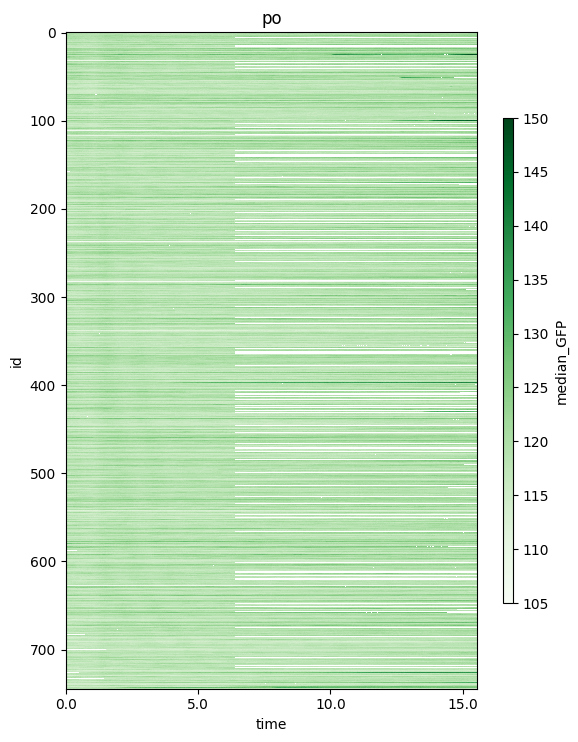

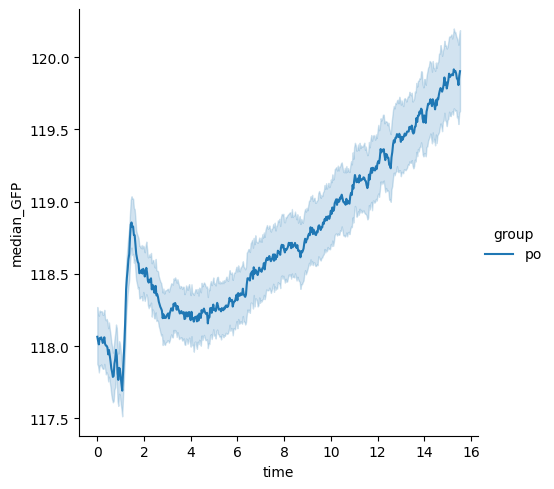


Data directory is /home/ianyang/alibylite/high_quality_data_analysis
Experiments available:
{0: '19330_2020_11_02_steadystate_glucose_1345m_2w2_00',
 1: '18572_2020_02_04_steady_2p0glc_2min_3z_mch5V_msn4msn2_00',
 2: '19394_2020_11_12_steadystate_glucose_1345m_2w0p1_00',
 3: '18367_2020_01_07_steady_0_1_gluc_2min_msn4msn2_00',
 4: '18464_2020_01_20_steadystate_glucose_756S_2min_mock_00',
 5: '18360_2020_01_04_steadystate_glucose_2min_01',
 6: '19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01',
 7: '20213_2021_09_07_steady_0p01glc_1344_1346_1347_00',
 8: '19316_2020_10_26_steadystate_glucose_144m_2w2_00',
 9: '18446_2020_01_08_steadystate_glucose_2w0p1_2min_01',
 10: '19554_2020_12_06_steadystate_glucose_2w0p01_900m_00',
 11: '19477_2020_11_27_steadystate_glucose_898_exposure_901_2w0p01_00',
 12: '19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00',
 13: '19392_2020_11_12_steadystate_glucose_898m_2w0p01_00',
 14: 'trash',
 15: '18589_2020_02_10_steadystate_glucose_898S_2w2_01'}

W

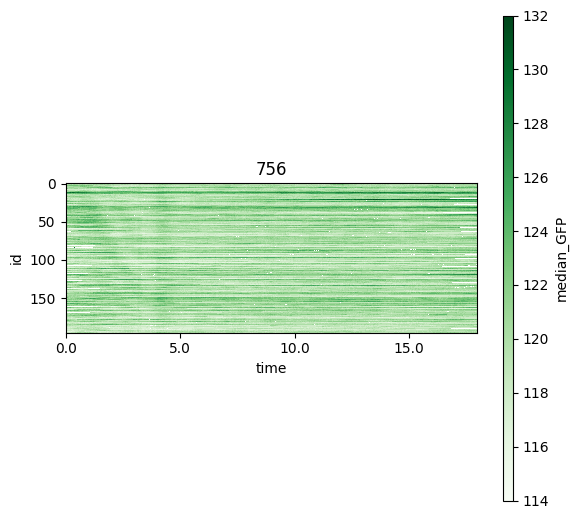

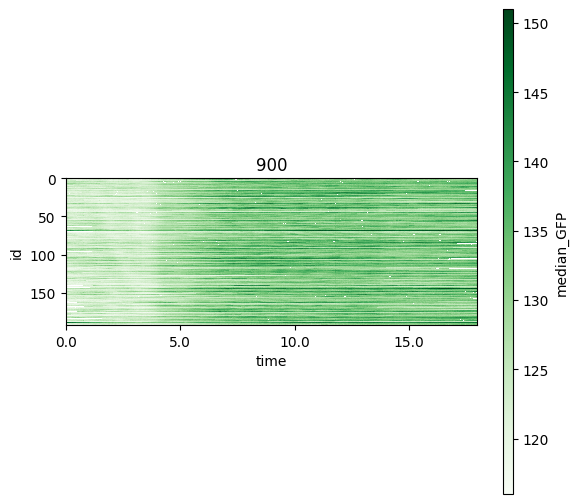

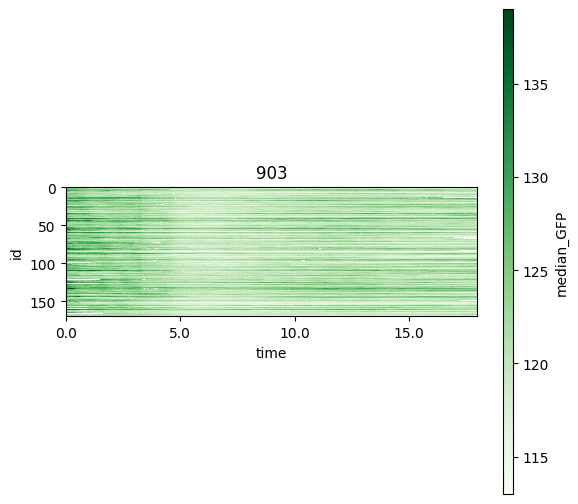

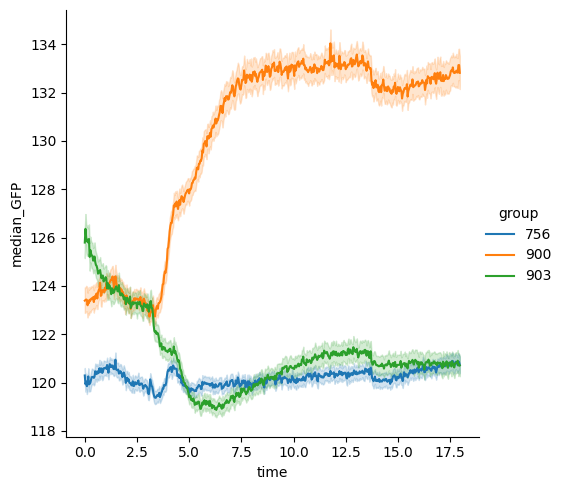


Data directory is /home/ianyang/alibylite/high_quality_data_analysis
Experiments available:
{0: '19330_2020_11_02_steadystate_glucose_1345m_2w2_00',
 1: '18572_2020_02_04_steady_2p0glc_2min_3z_mch5V_msn4msn2_00',
 2: '19394_2020_11_12_steadystate_glucose_1345m_2w0p1_00',
 3: '18367_2020_01_07_steady_0_1_gluc_2min_msn4msn2_00',
 4: '18464_2020_01_20_steadystate_glucose_756S_2min_mock_00',
 5: '18360_2020_01_04_steadystate_glucose_2min_01',
 6: '19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01',
 7: '20213_2021_09_07_steady_0p01glc_1344_1346_1347_00',
 8: '19316_2020_10_26_steadystate_glucose_144m_2w2_00',
 9: '18446_2020_01_08_steadystate_glucose_2w0p1_2min_01',
 10: '19554_2020_12_06_steadystate_glucose_2w0p01_900m_00',
 11: '19477_2020_11_27_steadystate_glucose_898_exposure_901_2w0p01_00',
 12: '19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00',
 13: '19392_2020_11_12_steadystate_glucose_898m_2w0p01_00',
 14: 'trash',
 15: '18589_2020_02_10_steadystate_glucose_898S_2w2_01'}

W

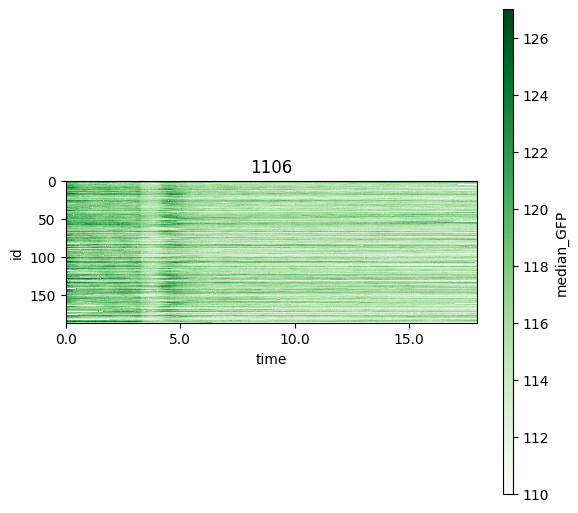

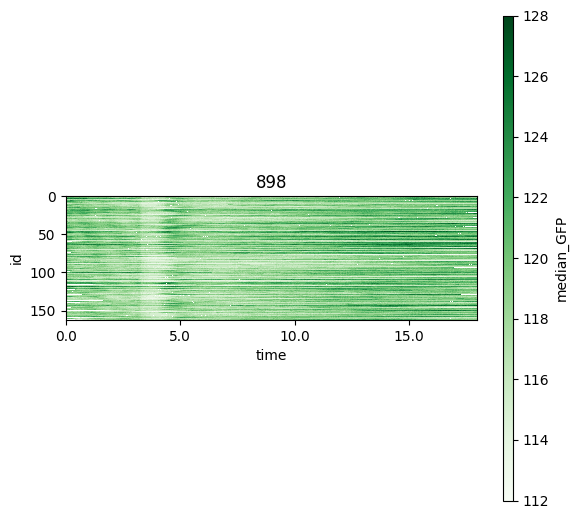

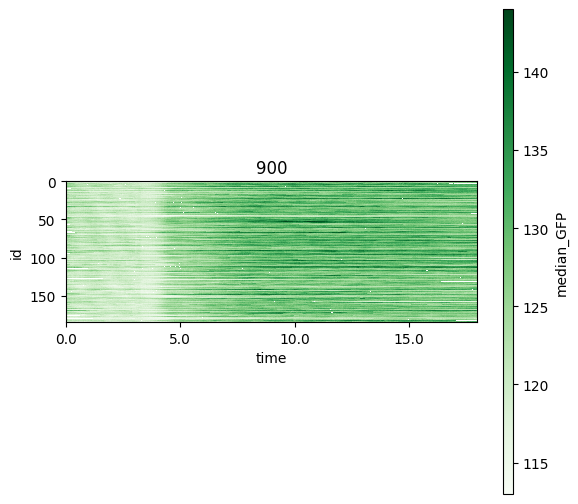

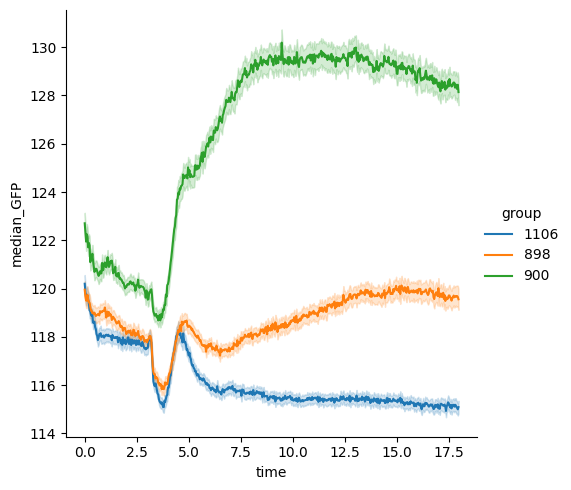


Data directory is /home/ianyang/alibylite/high_quality_data_analysis
Experiments available:
{0: '19330_2020_11_02_steadystate_glucose_1345m_2w2_00',
 1: '18572_2020_02_04_steady_2p0glc_2min_3z_mch5V_msn4msn2_00',
 2: '19394_2020_11_12_steadystate_glucose_1345m_2w0p1_00',
 3: '18367_2020_01_07_steady_0_1_gluc_2min_msn4msn2_00',
 4: '18464_2020_01_20_steadystate_glucose_756S_2min_mock_00',
 5: '18360_2020_01_04_steadystate_glucose_2min_01',
 6: '19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01',
 7: '20213_2021_09_07_steady_0p01glc_1344_1346_1347_00',
 8: '19316_2020_10_26_steadystate_glucose_144m_2w2_00',
 9: '18446_2020_01_08_steadystate_glucose_2w0p1_2min_01',
 10: '19554_2020_12_06_steadystate_glucose_2w0p01_900m_00',
 11: '19477_2020_11_27_steadystate_glucose_898_exposure_901_2w0p01_00',
 12: '19391_2020_11_12_steadystate_glucose_1345m_2w0p01_00',
 13: '19392_2020_11_12_steadystate_glucose_898m_2w0p01_00',
 14: 'trash',
 15: '18589_2020_02_10_steadystate_glucose_898S_2w2_01'}

W

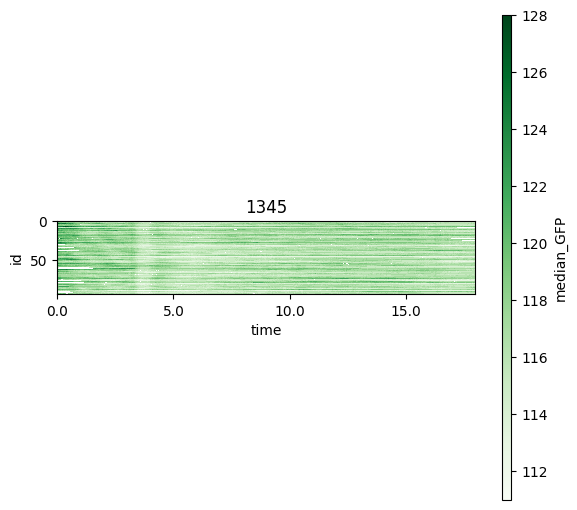

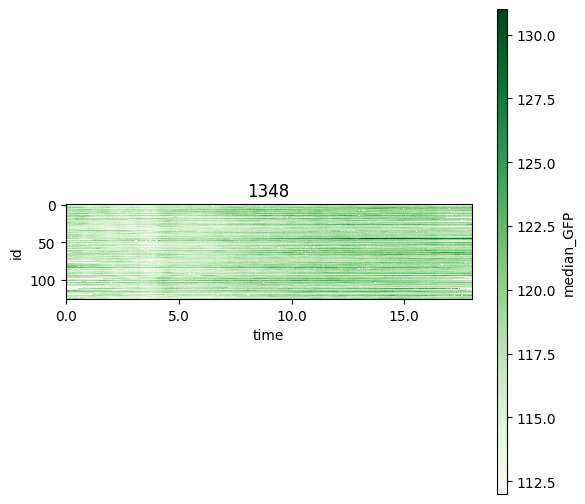

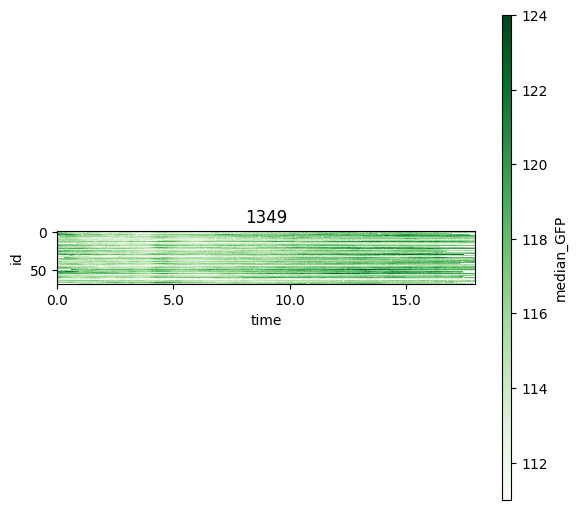

In [ ]:
import sys
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import traceback
from wela.dataloader import dataloader
from wela.imageviewer import ImageViewer, get_h5files
from wela.plotting import kymograph
from wela.sorting import sort_by_budding

# Configuration options
h5dir = "/home/ianyang/alibylite/high_quality_data_analysis/"
view = False
max_experiments = None  # Set to a number to limit experiments processed (useful for testing)

# Load experiment list
exp_list = pd.read_csv("/home/ianyang/alibylite/high_quality_data_analysis/exp_list.csv")
omids = exp_list["exp_name"].tolist()
if max_experiments:
    omids = omids[:max_experiments]
    print(f"Processing only first {max_experiments} experiments for testing")

# Remote server settings for viewing
server_info = {
    "host": "staffa.bio.ed.ac.uk",
    "username": "upload",
    "password": "gothamc1ty",
}

# Process each experiment
for i, omid in enumerate(omids):
    print(f"\nProcessing experiment {i+1}/{len(omids)}: {omid}")
    
    if view:
        try:
            h5files = get_h5files(h5dir, omid)
            if not h5files:
                print(f"No h5 files found for {omid}, skipping...")
                continue
                
            position = h5files[0]
            h5file = f"{h5dir}{omid}/{position}"
            iv = ImageViewer.remote(h5file, server_info, omid)
            tpt_end = 10
            no_cells = 6
            iv.view(
                trap_ids=iv.sample_traps_with_cells(
                    tpt_end=tpt_end, no_cells=no_cells
                ),
                tpt_end=tpt_end,
                channels_to_skip=["cy5"],
                no_rows=2,
            )
            sys.exit(0)
        except Exception as e:
            print(f"Error viewing experiment {omid}: {str(e)}")
            traceback.print_exc()
            continue
    else:
        # Try different key indices in order
        for attempt, (key_index, fl_channels) in enumerate([
            ("median_GFP", ["GFP"]), 
            ("median_GFP_Z", ["GFP_Z"]),
            ("budding", None)  # No fl_channels for budding
        ]):
            try:
                print(f"Attempt {attempt+1}: Using key_index={key_index}")
                dl = dataloader(h5dir, ".")
                
                # Configure dataloader
                if fl_channels:
                    dl.define_g2a_dict(fl_channels=fl_channels)
                else:
                    dl.define_g2a_dict()
                    
                # Load data
                dl.load(omid, key_index=key_index, cutoff=0.9)
                dl.save()
                
                # Plot kymographs
                groups = dl.df.group.unique()
                print(f"Found {len(groups)} groups: {', '.join(groups)}")
                
                for group in groups:
                    try:
                        _, buddings = dl.get_time_series("buddings", group=group)
                        sort_order = sort_by_budding(buddings)
                        fig_kymograph, ax_kymograph = kymograph(
                            dl.df[dl.df.group == group],
                            hue=key_index,
                            title=f"{omid} - {group}",
                            sort_order=sort_order,
                            returnfig=True
                        )
                        # Save the kymograph
                        output_file = f"./{omid}_{group}_kymograph.png"
                        fig_kymograph.savefig(output_file)
                        plt.close(fig_kymograph)
                        print(f"Saved kymograph to {output_file}")
                    except Exception as e:
                        print(f"Error plotting kymograph for group {group}: {str(e)}")
                        traceback.print_exc()
                
                # Plot means
                try:
                    mean_fig = sns.relplot(data=dl.df, x="time", y=key_index, kind="line", hue="group")
                    output_file = f"./{omid}_means_plot.png"
                    mean_fig.savefig(output_file)
                    plt.close()
                    print(f"Saved means plot to {output_file}")
                except Exception as e:
                    print(f"Error plotting means for {omid}: {str(e)}")
                    traceback.print_exc()
                
                # Successfully processed this experiment, break out of the attempts loop
                break
                
            except Exception as e:
                print(f"Error with key_index={key_index}: {str(e)}")
                if attempt == 2:  # Last attempt failed
                    print(f"All attempts failed for experiment {omid}, skipping...")

print("\nProcessing complete!")